In [75]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from src.metrics.self_reinforcement import extract_runs, summarise_runs

%load_ext autoreload
%autoreload 2

BASE       = Path('..') / 'results' / 'mas' / 'final_dataset'
W_VALUES   = [1, 2, 5]
TOPOS      = ['fc', 'star']
DATASETS   = ['gpqa', 'hiddenbench']
W_COLORS   = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS  = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
T_COLORS   = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_LABELS  = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS   = {'fc': 'Full-connected', 'star': 'Star'}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [76]:
def load_all():
    run_rows  = []
    rep_rows  = []
    task_rows = []

    for f in sorted(BASE.glob('**/*.json')):
        d    = json.loads(f.read_text())
        W    = d['W']
        ds   = d['dataset']
        topo = d.get('topology_name', 'fc')
        qid  = d['question_id']
        gt   = d['ground_truth']
        reps = d['repetitions']
        runs = extract_runs(reps)

        for row in runs:
            run_rows.append({'W': W, 'dataset': ds, 'topology': topo,
                             'qid': qid, 'ground_truth': gt, **row})

        for rep_idx, rep in enumerate(reps):
            T_r = len(rep['trajectory']) - 1
            init_votes = [rep['trajectory'][0]['phase_b'][i]['vote']
                          for i in range(rep['N'])]
            init_correct_frac = sum(v == gt for v in init_votes) / rep['N']
            rep_runs = [r for r in runs if r['rep_idx'] == rep_idx]
            slopes   = [r['slope'] for r in rep_runs]
            p_sr     = float(np.mean(np.array(slopes) > 0)) if slopes else np.nan
            mean_sl  = float(np.mean(slopes)) if slopes else np.nan
            rep_rows.append({
                'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
                'rep_idx': rep_idx, 'correct': rep['correct'],
                'duration_s': rep['duration_s'],
                'n_rounds': T_r,
                'init_correct_frac': init_correct_frac,
                'n_runs': len(rep_runs),
                'p_sr': p_sr, 'mean_slope': mean_sl,
            })

        summ = summarise_runs(runs)
        task_rows.append({
            'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
            'accuracy': float(np.mean([r['correct'] for r in reps])),
            'mean_rounds': float(np.mean([len(r['trajectory']) - 1 for r in reps])),
            **summ,
        })

    return (
        pd.DataFrame(run_rows),
        pd.DataFrame(rep_rows),
        pd.DataFrame(task_rows),
    )

runs_df, reps_df, tasks_df = load_all()
print(f'Run records : {len(runs_df):,}')
print(f'Rep records : {len(reps_df):,}')
print(f'Task records: {len(tasks_df):,}')
print()
print(tasks_df.groupby(['dataset','topology','W'])['n_runs'].sum().to_string())

Run records : 57,716
Rep records : 12,600
Task records: 420

dataset      topology  W
gpqa         fc        1    4468
                       2    4470
                       5    4559
             star      1    4703
                       2    4567
                       5    4643
hiddenbench  fc        1    5053
                       2    4863
                       5    4919
             star      1    5439
                       2    4997
                       5    5035


---
## Descriptive accounting: what gets measured and what gets dropped

In [77]:
from src.metrics.self_reinforcement import count_all_runs

total_counts        = {'n_total': 0, 'n_short': 0, 'n_kept': 0}
n_single_run_agents = 0
total_agent_trajs   = 0

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    reps = d['repetitions']
    c    = count_all_runs(reps)
    for k in total_counts:
        total_counts[k] += c[k]
    for rep in reps:
        traj = rep['trajectory']
        T_r  = len(traj) - 1
        N    = len(traj[0]['phase_b'])
        for ag in range(N):
            total_agent_trajs += 1
            votes = [traj[t]['phase_b'][ag]['vote'] for t in range(T_r + 1)]
            if len(set(votes)) == 1:
                n_single_run_agents += 1

n_total     = total_counts['n_total']
n_extracted = len(runs_df)
n_ceiling   = int(runs_df['ceiling_hit'].sum())
n_flat      = int((runs_df['slope'] == 0).sum())

print('─' * 58)
print('RUN FILTER ACCOUNTING')
print('─' * 58)
print(f'All stable runs (no length filter)  : {n_total:>7,}')
print(f'  dropped  length < 3               : {total_counts["n_short"]:>7,}  ({100*total_counts["n_short"]/n_total:.1f}%)')
print(f'  kept (length ≥ 3) = run records   : {n_extracted:>7,}  ({100*n_extracted/n_total:.1f}%)')
print(f'    of which flat β = 0             : {n_flat:>7,}  ({100*n_flat/n_extracted:.1f}%)')
print()
print('  Note: flat runs (β=0) are INCLUDED in p_SR denominator.')
print('  A flat run means no change in confidence — that is a valid')
print('  observation, not a missing value. p_SR = fraction with β>0.')
print()
print('─' * 58)
print('CEILING EFFECT  (confidence scale 1–10, ceiling = 10)')
print('─' * 58)
print(f'Runs ending at ceiling (end_conf=10): {n_ceiling:>7,}  ({100*n_ceiling/n_extracted:.1f}% of run records)')
print('→ ~1 in 5 runs ends at the ceiling.')
print('  These cannot drift further up, so p_SR is slightly underestimated.')
print('  A positive p_SR > 0.5 result is therefore conservative.')
print()
print('─' * 58)
print('NEVER-FLIPPING AGENTS')
print('─' * 58)
print(f'Agent trajectories total            : {total_agent_trajs:>7,}')
print(f'Never flipped (single vote)         : {n_single_run_agents:>7,}  ({100*n_single_run_agents/total_agent_trajs:.1f}%)')
print(f'Flipped at least once               : {total_agent_trajs-n_single_run_agents:>7,}  ({100*(total_agent_trajs-n_single_run_agents)/total_agent_trajs:.1f}%)')

──────────────────────────────────────────────────────────
RUN FILTER ACCOUNTING
──────────────────────────────────────────────────────────
All stable runs (no length filter)  : 103,147
  dropped  length < 3               :  45,431  (44.0%)
  kept (length ≥ 3) = run records   :  57,716  (56.0%)
    of which flat β = 0             :  10,167  (17.6%)

  Note: flat runs (β=0) are INCLUDED in p_SR denominator.
  A flat run means no change in confidence — that is a valid
  observation, not a missing value. p_SR = fraction with β>0.

──────────────────────────────────────────────────────────
CEILING EFFECT  (confidence scale 1–10, ceiling = 10)
──────────────────────────────────────────────────────────
Runs ending at ceiling (end_conf=10):  11,190  (19.4% of run records)
→ ~1 in 5 runs ends at the ceiling.
  These cannot drift further up, so p_SR is slightly underestimated.
  A positive p_SR > 0.5 result is therefore conservative.

──────────────────────────────────────────────────────────
N

In [78]:
35 * 2 * 3 * 2 * 30

12600

---
# Part 1 — Is There Self-Reinforcement?

**Null:** $P(\beta_{run} > 0) = 0.5$.  We look for $p_{SR} > 0.5$ in every cell.

In [79]:
# Prevalence table
grp = (tasks_df.groupby(['dataset','topology','W'])['p_sr']
       .agg(['mean','sem']).round(4).reset_index())
print(grp.to_string(index=False))

    dataset topology  W   mean    sem
       gpqa       fc  1 0.8458 0.0102
       gpqa       fc  2 0.8058 0.0132
       gpqa       fc  5 0.7521 0.0166
       gpqa     star  1 0.8043 0.0106
       gpqa     star  2 0.7685 0.0139
       gpqa     star  5 0.7352 0.0158
hiddenbench       fc  1 0.8397 0.0090
hiddenbench       fc  2 0.8579 0.0093
hiddenbench       fc  5 0.8211 0.0119
hiddenbench     star  1 0.8352 0.0100
hiddenbench     star  2 0.8271 0.0088
hiddenbench     star  5 0.7975 0.0091


In [80]:
# Sign test per cell
print('=== Binomial sign test: p_SR > 0.5 per (dataset, topology, W) ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sub = (tasks_df[(tasks_df['dataset']==ds) &
                            (tasks_df['topology']==topo) &
                            (tasks_df['W']==w)]['p_sr'].dropna())
            n_above = int((sub > 0.5).sum())
            res = sp_stats.binomtest(n_above, len(sub), p=0.5, alternative='greater')
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  '
                  f'p_sr={sub.mean():.3f}  above={n_above}/{len(sub)}  p={res.pvalue:.4f}')

=== Binomial sign test: p_SR > 0.5 per (dataset, topology, W) ===
  GPQA         fc    W=1  p_sr=0.846  above=35/35  p=0.0000
  GPQA         fc    W=2  p_sr=0.806  above=35/35  p=0.0000
  GPQA         fc    W=5  p_sr=0.752  above=35/35  p=0.0000
  GPQA         star  W=1  p_sr=0.804  above=35/35  p=0.0000
  GPQA         star  W=2  p_sr=0.768  above=35/35  p=0.0000
  GPQA         star  W=5  p_sr=0.735  above=35/35  p=0.0000
  HiddenBench  fc    W=1  p_sr=0.840  above=35/35  p=0.0000
  HiddenBench  fc    W=2  p_sr=0.858  above=35/35  p=0.0000
  HiddenBench  fc    W=5  p_sr=0.821  above=35/35  p=0.0000
  HiddenBench  star  W=1  p_sr=0.835  above=35/35  p=0.0000
  HiddenBench  star  W=2  p_sr=0.827  above=35/35  p=0.0000
  HiddenBench  star  W=5  p_sr=0.797  above=35/35  p=0.0000


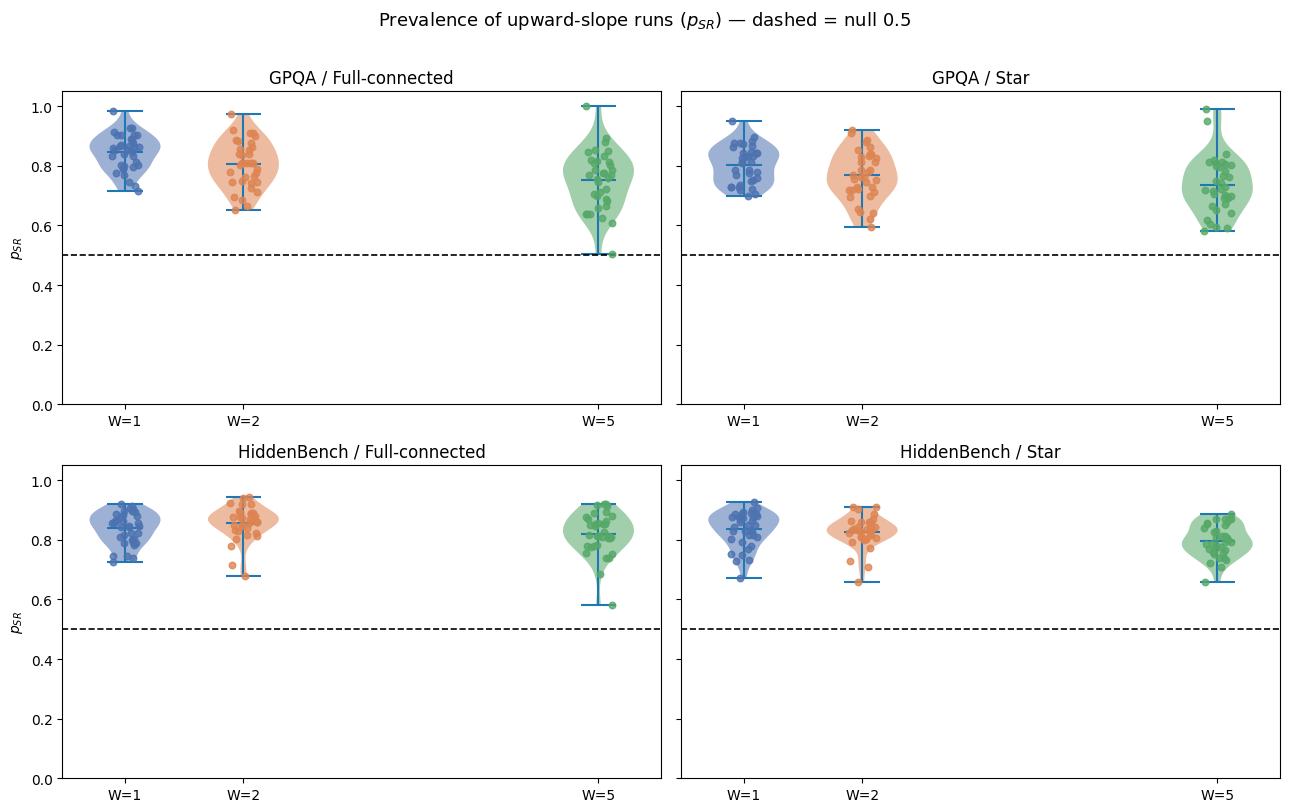

In [81]:
# p_SR violin: (dataset x topology) panels, x-axis = W
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        parts = ax.violinplot(
            [sub[sub['W']==w]['p_sr'].dropna().values for w in W_VALUES],
            positions=W_VALUES, widths=0.6,
            showmeans=True, showmedians=False,
        )
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(list(W_COLORS.values())[i])
            pc.set_alpha(0.55)
        for w in W_VALUES:
            vals   = sub[sub['W']==w]['p_sr'].dropna().values
            jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(vals))
            ax.scatter(w + jitter, vals, s=22, color=W_COLORS[w], alpha=0.8, zorder=3)
        ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2)
        ax.set_xticks(W_VALUES)
        ax.set_xticklabels([f'W={w}' for w in W_VALUES])
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.set_ylim(0, 1.05)
        if col == 0:
            ax.set_ylabel('$p_{SR}$')

fig.suptitle('Prevalence of upward-slope runs ($p_{SR}$) — dashed = null 0.5',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

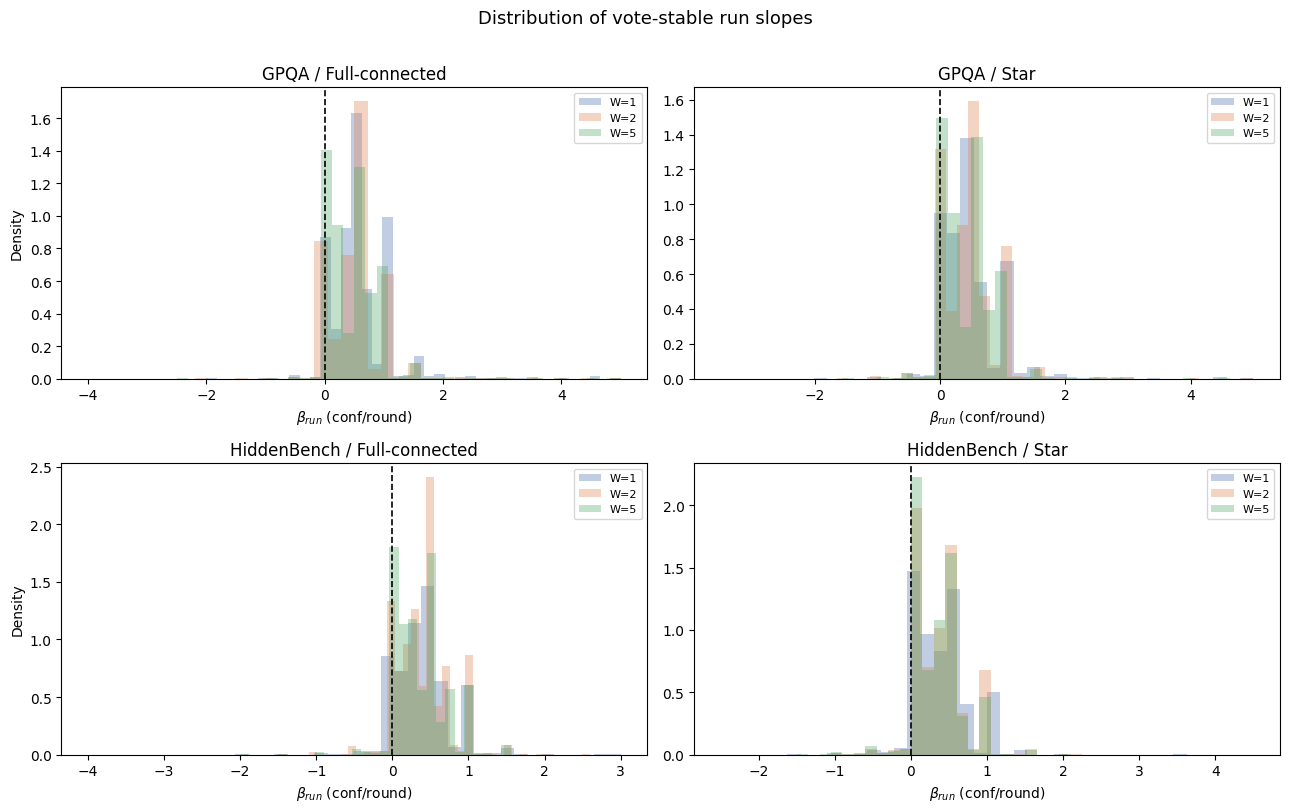

In [82]:
# Slope distribution
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = runs_df[(runs_df['dataset']==ds) & (runs_df['topology']==topo)]
        for w in W_VALUES:
            vals = sub[sub['W']==w]['slope'].dropna().values
            ax.hist(vals, bins=40, density=True, alpha=0.35,
                    color=W_COLORS[w], edgecolor='none', label=f'W={w}')
        ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
        ax.set_xlabel('$\\beta_{run}$ (conf/round)')
        ax.set_ylabel('Density' if col == 0 else '')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=8)

fig.suptitle('Distribution of vote-stable run slopes', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# Part 2 — Strength Scaling & Dataset / Topology Comparison

**Predicted ordering** (strength scaling): $\bar{\beta}(W=5) > \bar{\beta}(W=2) > \bar{\beta}(W=1)$ within each (dataset, topology).

In [83]:
# Mean slope table
ms = (tasks_df.groupby(['dataset','topology','W'])[['p_sr','mean_slope']]
      .mean().round(4))
print(ms.to_string())

                          p_sr  mean_slope
dataset     topology W                    
gpqa        fc       1  0.8458      0.5702
                     2  0.8058      0.5006
                     5  0.7521      0.4430
            star     1  0.8043      0.4940
                     2  0.7685      0.4497
                     5  0.7352      0.4006
hiddenbench fc       1  0.8397      0.4051
                     2  0.8579      0.4078
                     5  0.8211      0.3635
            star     1  0.8352      0.3622
                     2  0.8271      0.3675
                     5  0.7975      0.3249


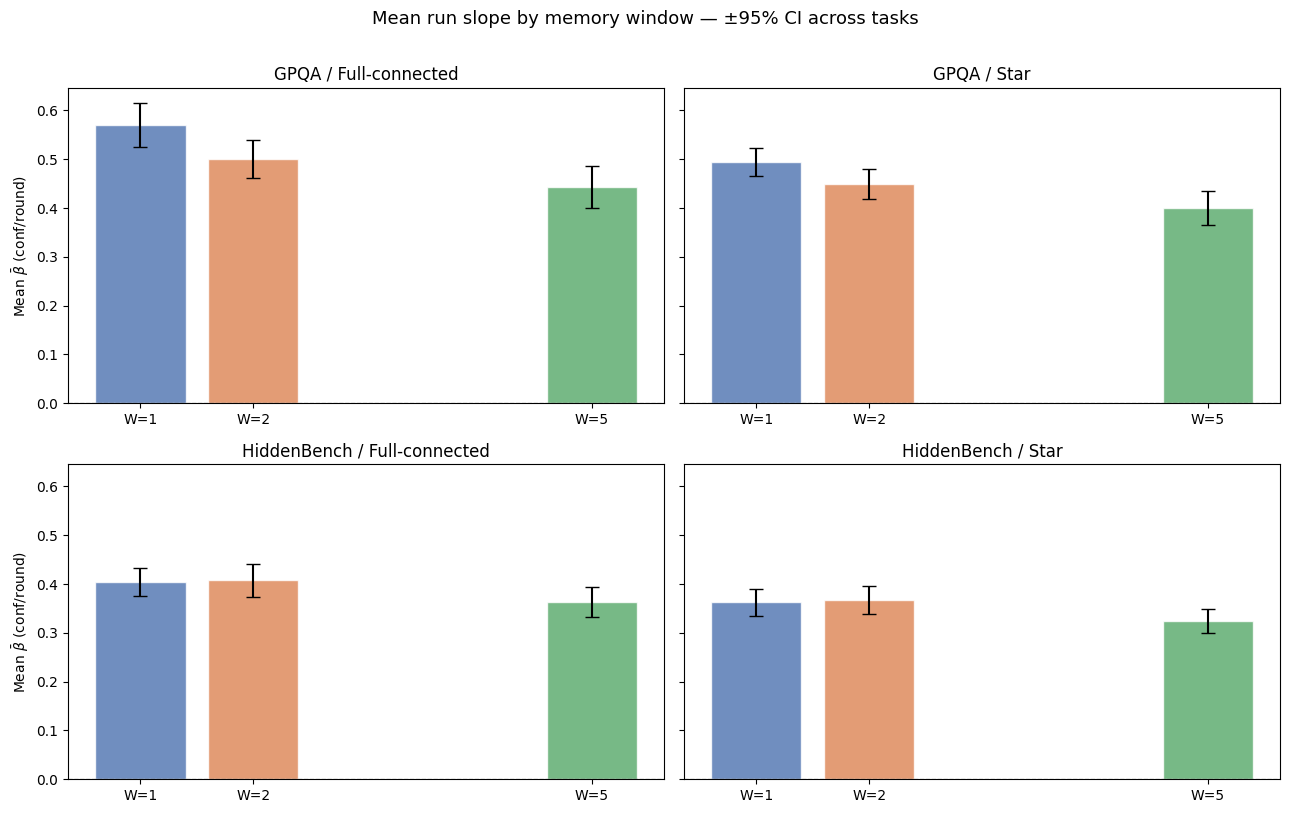

=== Kruskal-Wallis: W effect on mean_slope ===
  GPQA         fc     H=15.252  p=0.0005
  GPQA         star   H=18.466  p=0.0001
  HiddenBench  fc     H=3.623  p=0.1634
  HiddenBench  star   H=6.810  p=0.0332


In [84]:
# Bar chart: mean slope by W, faceted by (dataset, topology)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax   = axes[row][col]
        sub  = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        means = [sub[sub['W']==w]['mean_slope'].mean() for w in W_VALUES]
        sems  = [sub[sub['W']==w]['mean_slope'].sem()  for w in W_VALUES]
        ax.bar(W_VALUES, means, yerr=[1.96*s for s in sems],
               color=[W_COLORS[w] for w in W_VALUES],
               capsize=5, alpha=0.8, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(W_VALUES)
        ax.set_xticklabels([f'W={w}' for w in W_VALUES])
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        if col == 0:
            ax.set_ylabel('Mean $\\bar{\\beta}$ (conf/round)')

fig.suptitle('Mean run slope by memory window — ±95% CI across tasks',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Kruskal-Wallis
print('=== Kruskal-Wallis: W effect on mean_slope ===')
for ds in DATASETS:
    for topo in TOPOS:
        groups = [tasks_df[(tasks_df['dataset']==ds) &
                           (tasks_df['topology']==topo) &
                           (tasks_df['W']==w)]['mean_slope'].dropna().values
                  for w in W_VALUES]
        stat, p = sp_stats.kruskal(*groups)
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  H={stat:.3f}  p={p:.4f}')

In [85]:
# Topology comparison: fc vs star, per (dataset, W)
print('=== Topology comparison: fc vs star (MWU two-sided) ===')
for ds in DATASETS:
    for w in W_VALUES:
        fc   = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']=='fc')   & (tasks_df['W']==w)]['mean_slope'].dropna()
        star = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']=='star') & (tasks_df['W']==w)]['mean_slope'].dropna()
        stat, p = sp_stats.mannwhitneyu(fc, star, alternative='two-sided')
        print(f'  {DS_LABELS[ds]:12s} W={w}  fc={fc.mean():.3f}  star={star.mean():.3f}  p={p:.4f}')

=== Topology comparison: fc vs star (MWU two-sided) ===
  GPQA         W=1  fc=0.570  star=0.494  p=0.0171
  GPQA         W=2  fc=0.501  star=0.450  p=0.1128
  GPQA         W=5  fc=0.443  star=0.401  p=0.0908
  HiddenBench  W=1  fc=0.405  star=0.362  p=0.0227
  HiddenBench  W=2  fc=0.408  star=0.367  p=0.0742
  HiddenBench  W=5  fc=0.364  star=0.325  p=0.0188


In [86]:
# Dataset comparison: GPQA vs HiddenBench, per (topology, W)
print('=== Dataset comparison: GPQA vs HiddenBench (MWU two-sided) ===')
for topo in TOPOS:
    for w in W_VALUES:
        g = tasks_df[(tasks_df['dataset']=='gpqa')        & (tasks_df['topology']==topo) & (tasks_df['W']==w)]['mean_slope'].dropna()
        h = tasks_df[(tasks_df['dataset']=='hiddenbench') & (tasks_df['topology']==topo) & (tasks_df['W']==w)]['mean_slope'].dropna()
        stat, p = sp_stats.mannwhitneyu(g, h, alternative='two-sided')
        print(f'  {topo:5s} W={w}  GPQA={g.mean():.3f}  HiddenBench={h.mean():.3f}  p={p:.4f}')

=== Dataset comparison: GPQA vs HiddenBench (MWU two-sided) ===
  fc    W=1  GPQA=0.570  HiddenBench=0.405  p=0.0000
  fc    W=2  GPQA=0.501  HiddenBench=0.408  p=0.0025
  fc    W=5  GPQA=0.443  HiddenBench=0.364  p=0.0112
  star  W=1  GPQA=0.494  HiddenBench=0.362  p=0.0000
  star  W=2  GPQA=0.450  HiddenBench=0.367  p=0.0006
  star  W=5  GPQA=0.401  HiddenBench=0.325  p=0.0007


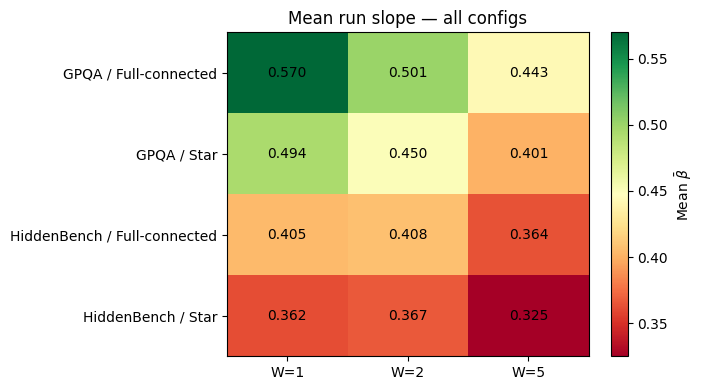

In [87]:
# Combined heatmap: mean_slope for all (dataset, topology, W) cells
pivot = (tasks_df.groupby(['dataset','topology','W'])['mean_slope']
         .mean().unstack('W').round(3))
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(W_VALUES)))
ax.set_xticklabels([f'W={w}' for w in W_VALUES])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{DS_LABELS.get(ds,ds)} / {T_LABELS.get(t,t)}'
                    for ds, t in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(W_VALUES)):
        ax.text(j, i, f'{pivot.values[i,j]:.3f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='Mean $\\bar{\\beta}$')
ax.set_title('Mean run slope — all configs')
plt.tight_layout()
plt.show()

---
# Part 3 — What Drives Self-Reinforcement?

Four candidate drivers:
1. **Initial correctness** — agents starting on the correct answer
2. **Run length** — longer stable runs accumulate more slope
3. **Terminal vs non-terminal** — runs that persist to the end
4. **Correct-vote vs incorrect-vote** — whether the held opinion is right

In [88]:
# Driver 1: initial correctness ~ mean_slope (rep level)
print('=== Rep-level Pearson r: init_correct_frac ~ mean_slope ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sub = (reps_df[(reps_df['dataset']==ds) &
                           (reps_df['topology']==topo) &
                           (reps_df['W']==w)].dropna(subset=['mean_slope']))
            r, p = sp_stats.pearsonr(sub['init_correct_frac'], sub['mean_slope'])
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  r={r:.3f}  p={p:.4f}')

=== Rep-level Pearson r: init_correct_frac ~ mean_slope ===
  GPQA         fc    W=1  r=0.227  p=0.0000
  GPQA         fc    W=2  r=0.264  p=0.0000
  GPQA         fc    W=5  r=0.293  p=0.0000
  GPQA         star  W=1  r=0.072  p=0.0202
  GPQA         star  W=2  r=0.086  p=0.0052
  GPQA         star  W=5  r=0.140  p=0.0000
  HiddenBench  fc    W=1  r=-0.131  p=0.0000
  HiddenBench  fc    W=2  r=-0.100  p=0.0012
  HiddenBench  fc    W=5  r=-0.114  p=0.0002
  HiddenBench  star  W=1  r=-0.037  p=0.2260
  HiddenBench  star  W=2  r=-0.076  p=0.0139
  HiddenBench  star  W=5  r=-0.064  p=0.0378


In [89]:
# Driver 2: run length ~ slope (run level)
print('=== Run-level Spearman r: run_length ~ slope ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = runs_df[(runs_df['dataset']==ds) & (runs_df['topology']==topo)].dropna(subset=['slope'])
        r, p = sp_stats.spearmanr(sub['run_length'], sub['slope'])
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  ρ={r:.3f}  p={p:.4f}  n={len(sub)}')

=== Run-level Spearman r: run_length ~ slope ===
  GPQA         fc     ρ=-0.193  p=0.0000  n=13497
  GPQA         star   ρ=-0.174  p=0.0000  n=13913
  HiddenBench  fc     ρ=-0.381  p=0.0000  n=14835
  HiddenBench  star   ρ=-0.410  p=0.0000  n=15471


In [90]:
# Driver 3: terminal vs non-terminal
print('=== Terminal vs non-terminal run slopes ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = runs_df[(runs_df['dataset']==ds) & (runs_df['topology']==topo)].dropna(subset=['slope'])
        t  = sub[sub['terminal']]['slope']
        nt = sub[~sub['terminal']]['slope']
        if len(t) < 2 or len(nt) < 2:
            continue
        stat, p = sp_stats.mannwhitneyu(t, nt, alternative='two-sided')
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  '
              f'terminal={t.mean():.3f} (n={len(t)})  '
              f'non-terminal={nt.mean():.3f} (n={len(nt)})  p={p:.4f}')

=== Terminal vs non-terminal run slopes ===
  GPQA         fc     terminal=0.511 (n=12567)  non-terminal=0.371 (n=930)  p=0.0000
  GPQA         star   terminal=0.458 (n=12555)  non-terminal=0.331 (n=1358)  p=0.0000
  HiddenBench  fc     terminal=0.415 (n=12389)  non-terminal=0.238 (n=2446)  p=0.0000
  HiddenBench  star   terminal=0.368 (n=12385)  non-terminal=0.265 (n=3086)  p=0.0000


In [91]:
# Driver 4: correct-vote vs incorrect-vote
print('=== Correct-vote vs incorrect-vote run slopes ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub = runs_df[(runs_df['dataset']==ds) & (runs_df['topology']==topo)].dropna(subset=['slope','correct_vote'])
        c  = sub[sub['correct_vote']==True]['slope']
        ic = sub[sub['correct_vote']==False]['slope']
        stat, p = sp_stats.mannwhitneyu(c, ic, alternative='two-sided')
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  '
              f'correct={c.mean():.3f} (n={len(c)})  '
              f'incorrect={ic.mean():.3f} (n={len(ic)})  p={p:.4f}')

=== Correct-vote vs incorrect-vote run slopes ===
  GPQA         fc     correct=0.552 (n=6628)  incorrect=0.452 (n=6869)  p=0.0000
  GPQA         star   correct=0.468 (n=6533)  incorrect=0.426 (n=7380)  p=0.0000
  HiddenBench  fc     correct=0.404 (n=4439)  incorrect=0.378 (n=10396)  p=0.0001
  HiddenBench  star   correct=0.359 (n=4455)  incorrect=0.342 (n=11016)  p=0.0014


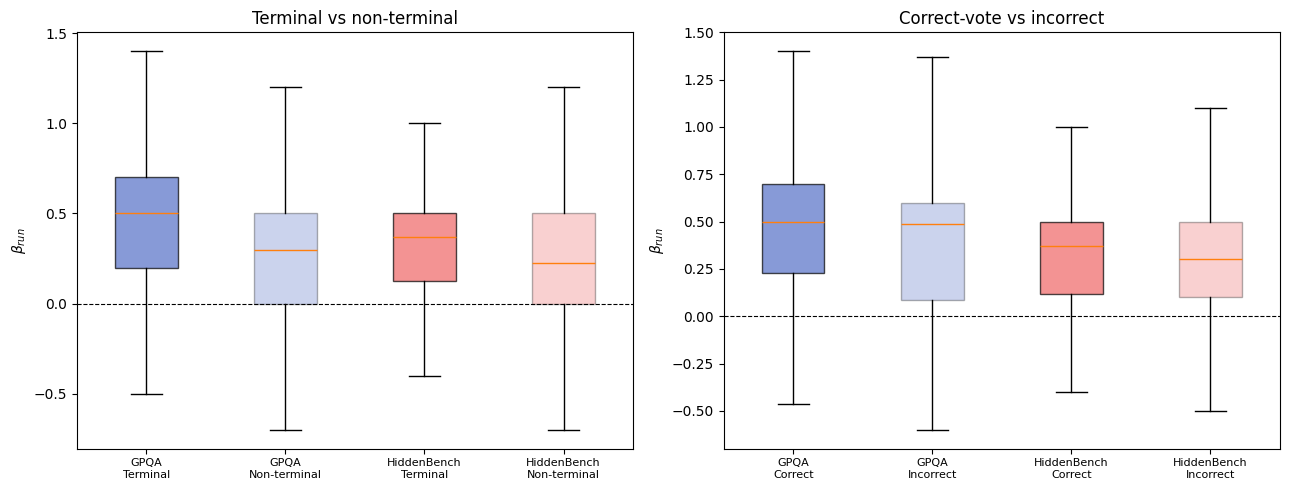

In [92]:
# Driver summary: boxplot terminal/non-terminal and correct/incorrect
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (key, label, labels) in zip(axes, [
    ('terminal',     'Terminal vs non-terminal', {True: 'Terminal', False: 'Non-terminal'}),
    ('correct_vote', 'Correct-vote vs incorrect', {True: 'Correct', False: 'Incorrect'}),
]):
    data, tick_labels = [], []
    for ds in DATASETS:
        for val in [True, False]:
            sub = runs_df[(runs_df['dataset']==ds) &
                          runs_df[key].eq(val)]['slope'].dropna().values
            data.append(sub)
            tick_labels.append(f'{DS_LABELS[ds]}\n{labels[val]}')
    bp = ax.boxplot(data, patch_artist=True, notch=False, showfliers=False)
    colors = [DS_COLORS['gpqa'], DS_COLORS['gpqa'],
              DS_COLORS['hiddenbench'], DS_COLORS['hiddenbench']]
    alphas = [0.7, 0.3, 0.7, 0.3]
    for patch, c, a in zip(bp['boxes'], colors, alphas):
        patch.set_facecolor(c)
        patch.set_alpha(a)
    ax.set_xticks(range(1, len(tick_labels)+1))
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylabel('$\\beta_{run}$')
    ax.set_title(label)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

---
# Part 4 — Impact on System Performance

## 4a. Self-Reinforcement and Accuracy

In [93]:
# Point-biserial at rep level
print('=== Rep-level rpb: correct ~ mean_slope ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sub = (reps_df[(reps_df['dataset']==ds) &
                           (reps_df['topology']==topo) &
                           (reps_df['W']==w)].dropna(subset=['mean_slope']))
            r, p = sp_stats.pointbiserialr(sub['correct'].astype(int), sub['mean_slope'])
            acc  = sub.groupby('correct')['mean_slope'].mean()
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  '
                  f'rpb={r:.3f}  p={p:.4f}  '
                  f'correct_slope={acc.get(True, float("nan")):.3f}  '
                  f'incorrect_slope={acc.get(False, float("nan")):.3f}')

=== Rep-level rpb: correct ~ mean_slope ===
  GPQA         fc    W=1  rpb=0.127  p=0.0000  correct_slope=0.623  incorrect_slope=0.542
  GPQA         fc    W=2  rpb=0.182  p=0.0000  correct_slope=0.564  incorrect_slope=0.462
  GPQA         fc    W=5  rpb=0.164  p=0.0000  correct_slope=0.507  incorrect_slope=0.410
  GPQA         star  W=1  rpb=0.065  p=0.0354  correct_slope=0.535  incorrect_slope=0.497
  GPQA         star  W=2  rpb=0.067  p=0.0303  correct_slope=0.482  incorrect_slope=0.445
  GPQA         star  W=5  rpb=0.080  p=0.0096  correct_slope=0.436  incorrect_slope=0.394
  HiddenBench  fc    W=1  rpb=0.032  p=0.3004  correct_slope=0.438  incorrect_slope=0.421
  HiddenBench  fc    W=2  rpb=-0.009  p=0.7662  correct_slope=0.420  incorrect_slope=0.425
  HiddenBench  fc    W=5  rpb=-0.023  p=0.4620  correct_slope=0.375  incorrect_slope=0.387
  HiddenBench  star  W=1  rpb=-0.033  p=0.2853  correct_slope=0.369  incorrect_slope=0.385
  HiddenBench  star  W=2  rpb=-0.020  p=0.5247  corre

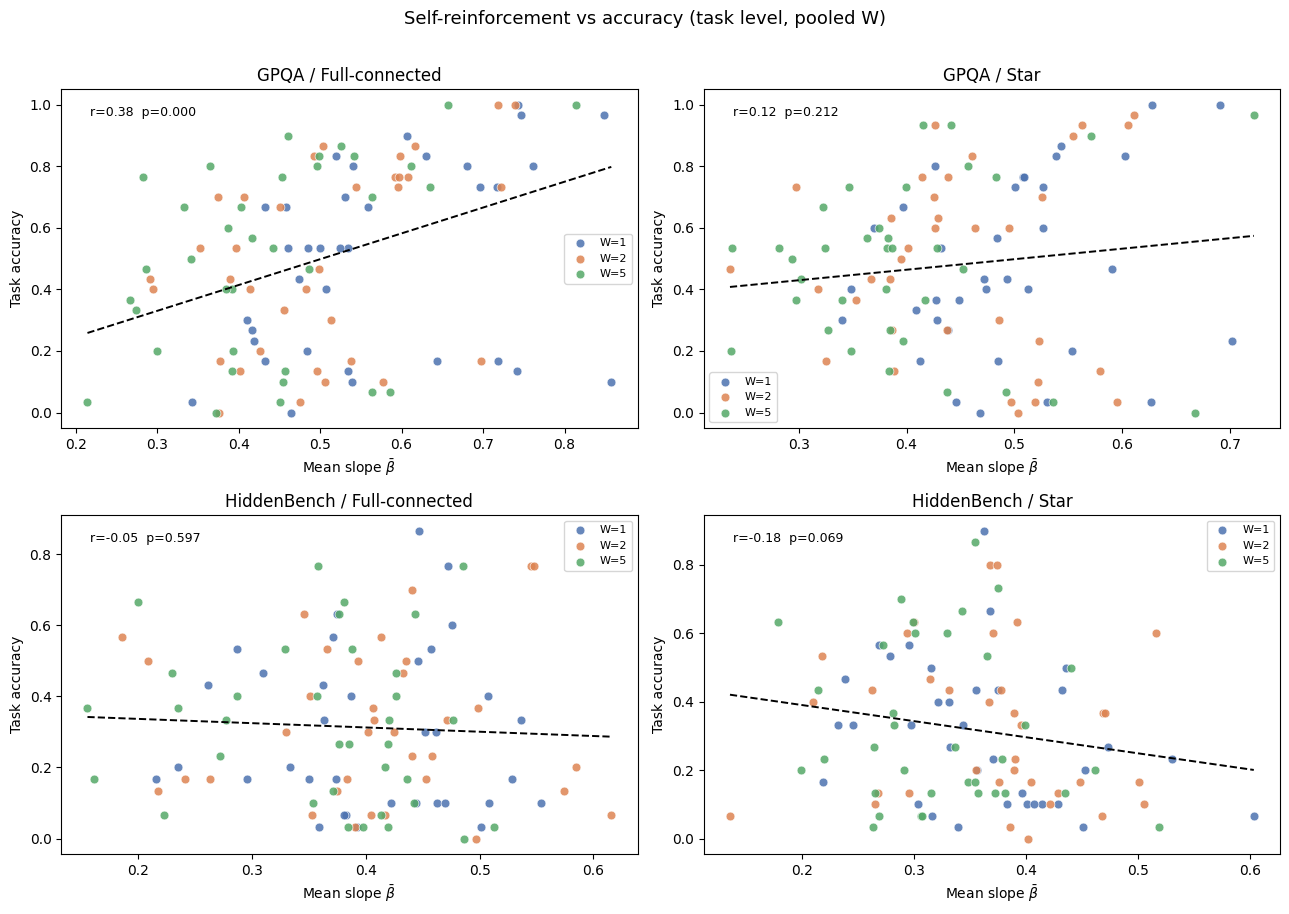

In [94]:
# Task-level scatter: mean_slope vs accuracy, faceted by (dataset, topology)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        for w in W_VALUES:
            sw = sub[sub['W']==w].dropna(subset=['mean_slope','accuracy'])
            ax.scatter(sw['mean_slope'], sw['accuracy'],
                       s=40, color=W_COLORS[w], alpha=0.85,
                       label=f'W={w}', edgecolors='white', linewidths=0.5)
        all_s = sub.dropna(subset=['mean_slope','accuracy'])
        m, b  = np.polyfit(all_s['mean_slope'], all_s['accuracy'], 1)
        xs    = np.linspace(all_s['mean_slope'].min(), all_s['mean_slope'].max(), 50)
        ax.plot(xs, m*xs + b, color='black', linewidth=1.4, linestyle='--')
        r, p  = sp_stats.pearsonr(all_s['mean_slope'], all_s['accuracy'])
        ax.text(0.05, 0.95, f'r={r:.2f}  p={p:.3f}',
                transform=ax.transAxes, fontsize=9, va='top')
        ax.set_xlabel('Mean slope $\\bar{\\beta}$')
        ax.set_ylabel('Task accuracy')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=8)

fig.suptitle('Self-reinforcement vs accuracy (task level, pooled W)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [95]:
# Median-split accuracy
print('=== Accuracy: high-SR vs low-SR reps (pooled W, per dataset/topology) ===')
for ds in DATASETS:
    for topo in TOPOS:
        sub    = reps_df[(reps_df['dataset']==ds) & (reps_df['topology']==topo)].dropna(subset=['mean_slope'])
        median = sub['mean_slope'].median()
        hi     = sub[sub['mean_slope'] >  median]['correct'].mean()
        lo     = sub[sub['mean_slope'] <= median]['correct'].mean()
        print(f'  {DS_LABELS[ds]:12s} {topo:5s}  '
              f'high-SR={hi:.3f}  low-SR={lo:.3f}  diff={hi-lo:+.3f}')

=== Accuracy: high-SR vs low-SR reps (pooled W, per dataset/topology) ===
  GPQA         fc     high-SR=0.571  low-SR=0.434  diff=+0.137
  GPQA         star   high-SR=0.512  low-SR=0.449  diff=+0.063
  HiddenBench  fc     high-SR=0.316  low-SR=0.311  diff=+0.005
  HiddenBench  star   high-SR=0.312  low-SR=0.326  diff=-0.013


## 4b. Self-Reinforcement and Efficiency (rounds to consensus)

In [96]:
# Spearman at rep level
print('=== Rep-level Spearman: n_rounds ~ mean_slope ===')
for ds in DATASETS:
    for topo in TOPOS:
        for w in W_VALUES:
            sub = (reps_df[(reps_df['dataset']==ds) &
                           (reps_df['topology']==topo) &
                           (reps_df['W']==w)].dropna(subset=['mean_slope']))
            r, p = sp_stats.spearmanr(sub['mean_slope'], sub['n_rounds'])
            print(f'  {DS_LABELS[ds]:12s} {topo:5s} W={w}  '
                  f'ρ={r:.3f}  p={p:.4f}  mean_rounds={sub["n_rounds"].mean():.2f}')

=== Rep-level Spearman: n_rounds ~ mean_slope ===
  GPQA         fc    W=1  ρ=-0.658  p=0.0000  mean_rounds=4.00
  GPQA         fc    W=2  ρ=-0.697  p=0.0000  mean_rounds=3.95
  GPQA         fc    W=5  ρ=-0.815  p=0.0000  mean_rounds=4.19
  GPQA         star  W=1  ρ=-0.637  p=0.0000  mean_rounds=4.50
  GPQA         star  W=2  ρ=-0.710  p=0.0000  mean_rounds=4.33
  GPQA         star  W=5  ρ=-0.755  p=0.0000  mean_rounds=4.60
  HiddenBench  fc    W=1  ρ=-0.727  p=0.0000  mean_rounds=6.49
  HiddenBench  fc    W=2  ρ=-0.750  p=0.0000  mean_rounds=6.01
  HiddenBench  fc    W=5  ρ=-0.828  p=0.0000  mean_rounds=6.47
  HiddenBench  star  W=1  ρ=-0.755  p=0.0000  mean_rounds=7.78
  HiddenBench  star  W=2  ρ=-0.781  p=0.0000  mean_rounds=7.15
  HiddenBench  star  W=5  ρ=-0.768  p=0.0000  mean_rounds=7.22


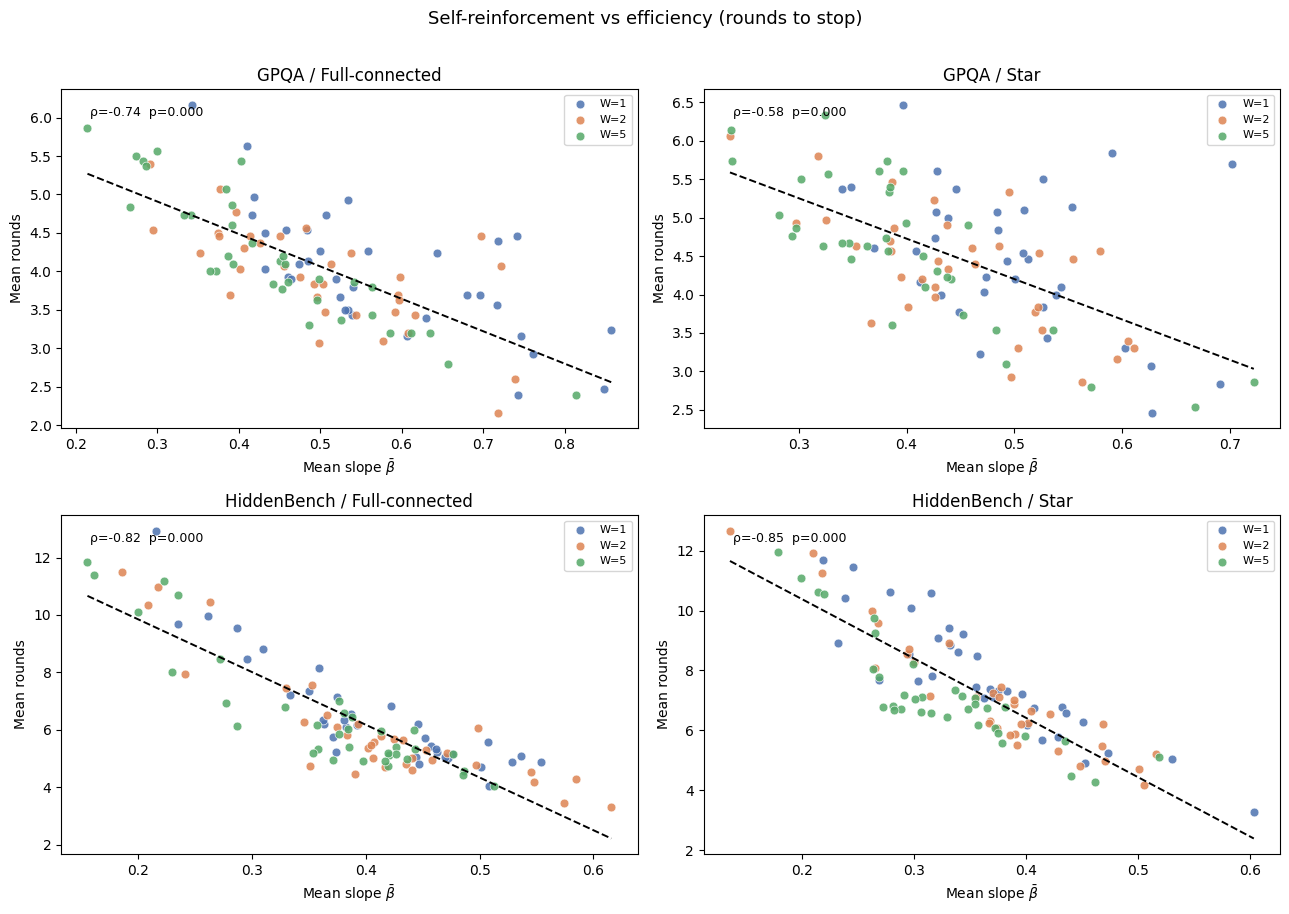

In [97]:
# Task-level scatter: mean_slope vs mean_rounds, faceted
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, ds in enumerate(DATASETS):
    for col, topo in enumerate(TOPOS):
        ax  = axes[row][col]
        sub = tasks_df[(tasks_df['dataset']==ds) & (tasks_df['topology']==topo)]
        for w in W_VALUES:
            sw = sub[sub['W']==w].dropna(subset=['mean_slope','mean_rounds'])
            ax.scatter(sw['mean_slope'], sw['mean_rounds'],
                       s=40, color=W_COLORS[w], alpha=0.85,
                       label=f'W={w}', edgecolors='white', linewidths=0.5)
        all_s = sub.dropna(subset=['mean_slope','mean_rounds'])
        m, b  = np.polyfit(all_s['mean_slope'], all_s['mean_rounds'], 1)
        xs    = np.linspace(all_s['mean_slope'].min(), all_s['mean_slope'].max(), 50)
        ax.plot(xs, m*xs + b, color='black', linewidth=1.4, linestyle='--')
        r, p  = sp_stats.spearmanr(all_s['mean_slope'], all_s['mean_rounds'])
        ax.text(0.05, 0.95, f'ρ={r:.2f}  p={p:.3f}',
                transform=ax.transAxes, fontsize=9, va='top')
        ax.set_xlabel('Mean slope $\\bar{\\beta}$')
        ax.set_ylabel('Mean rounds')
        ax.set_title(f'{DS_LABELS[ds]} / {T_LABELS[topo]}')
        ax.legend(fontsize=8)

fig.suptitle('Self-reinforcement vs efficiency (rounds to stop)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [98]:
# Tertile accuracy analysis: does high SR hurt accuracy more on hard tasks?
print('=== Accuracy by slope tertile (rep level) ===')
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    for topo in TOPOS:
        print(f'  {T_LABELS[topo]}')
        for w in W_VALUES:
            sub = (reps_df[(reps_df['dataset']==ds) &
                           (reps_df['topology']==topo) &
                           (reps_df['W']==w)].dropna(subset=['mean_slope']))
            q33, q67 = sub['mean_slope'].quantile([0.33, 0.67])
            lo  = sub[sub['mean_slope'] <= q33]['correct'].mean()
            mid = sub[(sub['mean_slope'] > q33) & (sub['mean_slope'] <= q67)]['correct'].mean()
            hi  = sub[sub['mean_slope'] >  q67]['correct'].mean()
            print(f'    W={w}  low={lo:.3f}  mid={mid:.3f}  high={hi:.3f}')

=== Accuracy by slope tertile (rep level) ===

GPQA
  Full-connected
    W=1  low=0.410  mid=0.514  high=0.586
    W=2  low=0.410  mid=0.493  high=0.613
    W=5  low=0.418  mid=0.508  high=0.598
  Star
    W=1  low=0.442  mid=0.455  high=0.530
    W=2  low=0.428  mid=0.506  high=0.532
    W=5  low=0.429  mid=0.484  high=0.523

HiddenBench
  Full-connected
    W=1  low=0.288  mid=0.309  high=0.300
    W=2  low=0.324  mid=0.319  high=0.318
    W=5  low=0.350  mid=0.296  high=0.316
  Star
    W=1  low=0.303  mid=0.320  high=0.288
    W=2  low=0.337  mid=0.305  high=0.333
    W=5  low=0.329  mid=0.333  high=0.323


---
# Part 5 — Overview Table and Recommendations

---
# Part 5 — When Does SR Occur? Subgroup Analysis

Five binary / categorical splits, all at the **run level** (slope as response).
Each split tests whether SR intensity differs across a structural or contextual condition.

In [100]:
from collections import Counter as _Counter

# ── Annotate runs_df with rep-level context ───────────────────────────────────

# 1. never_flip: rep has only one unique vote (single run spanning full trajectory)
never_flip_set = set()
init_dist_map  = {}   # (dataset, topology, W, qid, rep_idx) -> dist label

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W, ds, topo, qid = d['W'], d['dataset'], d.get('topology_name','fc'), d['question_id']
    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        T_r  = len(traj) - 1
        N    = len(traj[0]['phase_b'])
        all_votes = [traj[t]['phase_b'][i]['vote']
                     for t in range(T_r + 1) for i in range(N)]
        # per-agent votes across all rounds
        agent_votes = [[traj[t]['phase_b'][i]['vote'] for t in range(T_r+1)]
                       for i in range(N)]
        flipped = any(len(set(av)) > 1 for av in agent_votes)
        if not flipped:
            never_flip_set.add((ds, topo, W, qid, rep_idx))

        init_votes = [traj[0]['phase_b'][i]['vote'] for i in range(N)]
        cnts = sorted(_Counter(init_votes).values(), reverse=True)
        while len(cnts) < 4: cnts.append(0)
        init_dist_map[(ds, topo, W, qid, rep_idx)] = '-'.join(str(c) for c in cnts)

runs_df['never_flip'] = runs_df.apply(
    lambda r: (r['dataset'], r['topology'], r['W'], r['qid'], r['rep_idx']) in never_flip_set,
    axis=1
)
runs_df['init_dist'] = runs_df.apply(
    lambda r: init_dist_map.get((r['dataset'], r['topology'], r['W'], r['qid'], r['rep_idx']), None),
    axis=1
)

# 2. initially_correct: fraction of agents on correct vote at round 0
#    carried from reps_df via (dataset, topology, W, qid, rep_idx)
init_correct_map = reps_df.set_index(
    ['dataset','topology','W','qid','rep_idx'])['init_correct_frac'].to_dict()
runs_df['init_correct_frac'] = runs_df.apply(
    lambda r: init_correct_map.get((r['dataset'],r['topology'],r['W'],r['qid'],r['rep_idx'])), axis=1
)
runs_df['init_majority_correct'] = runs_df['init_correct_frac'] > 0.5

# ── Summary table ─────────────────────────────────────────────────────────────
def _group_stats(mask):
    s = runs_df[mask]['slope'].dropna()
    p_sr = float((s > 0).mean())
    return p_sr, float(s.mean()), len(s)

splits = {
    'Ceiling hit':         runs_df['ceiling_hit'] == True,
    'No ceiling':          runs_df['ceiling_hit'] == False,
    'Terminal':            runs_df['terminal'] == True,
    'Non-terminal':        runs_df['terminal'] == False,
    'Init majority correct': runs_df['init_majority_correct'] == True,
    'Init majority wrong':   runs_df['init_majority_correct'] == False,
    'Never flip (rep)':    runs_df['never_flip'] == True,
    'Flip at some point':  runs_df['never_flip'] == False,
}

rows = []
for label, mask in splits.items():
    p_sr, ms, n = _group_stats(mask)
    rows.append({'Group': label, 'n_runs': n, 'p_SR': round(p_sr,3), 'mean_slope': round(ms,3)})
print(pd.DataFrame(rows).to_string(index=False))

                Group  n_runs  p_SR  mean_slope
          Ceiling hit   11190 0.914       0.526
           No ceiling   46526 0.779       0.390
             Terminal   49896 0.822       0.438
         Non-terminal    7820 0.701       0.281
Init majority correct    8169 0.855       0.588
  Init majority wrong   49547 0.797       0.388
     Never flip (rep)    6192 0.929       0.754
   Flip at some point   51524 0.791       0.376


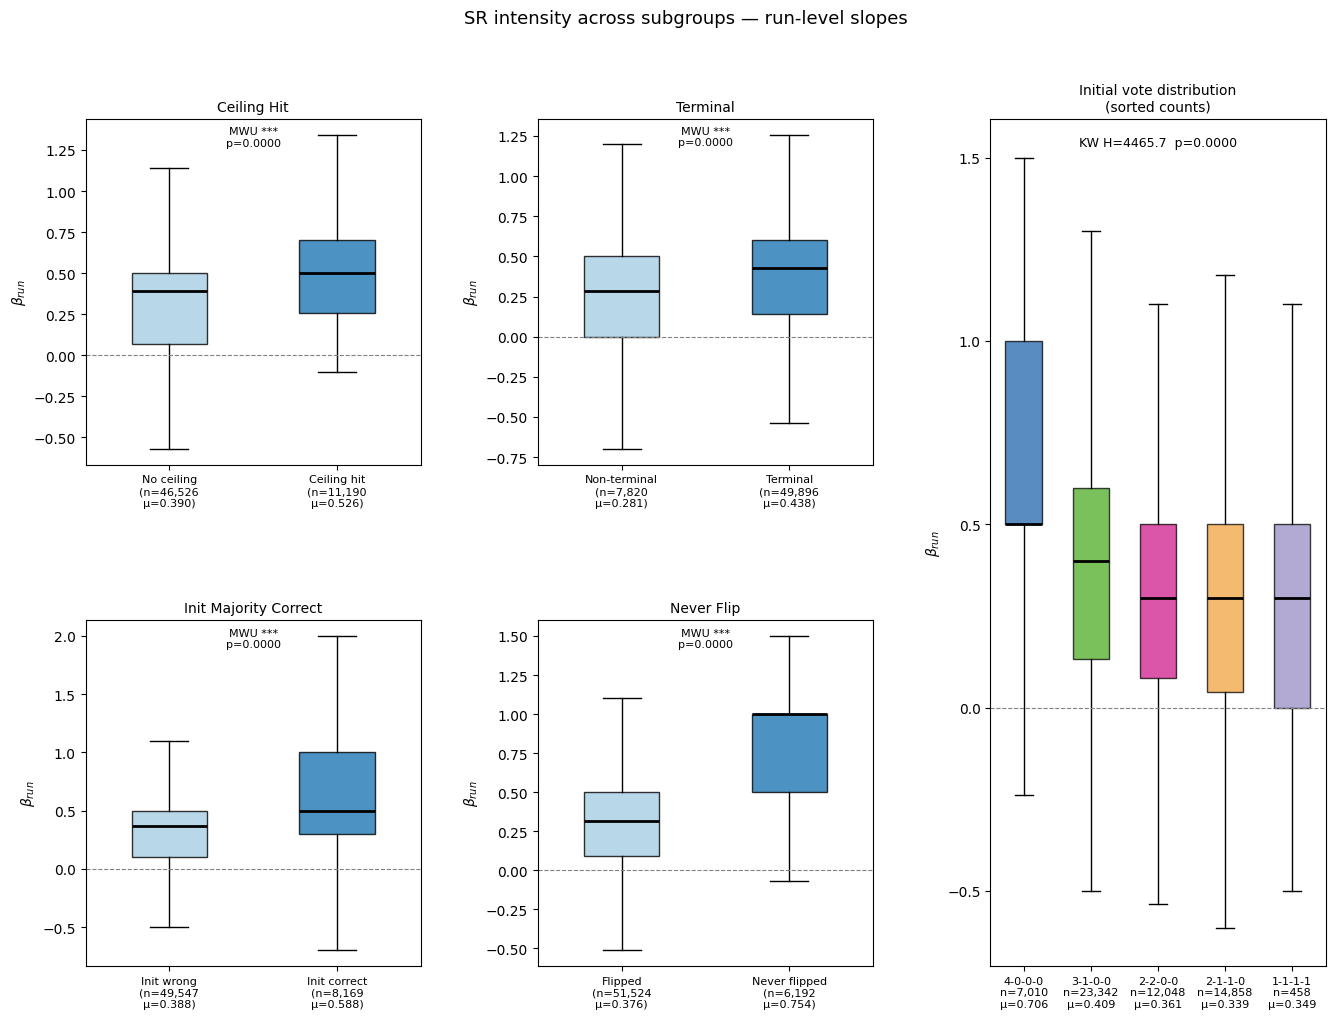


=== MWU tests for binary splits ===
  No ceiling           μ=0.390  vs  Ceiling hit          μ=0.526  p=0.0000
  Non-terminal         μ=0.281  vs  Terminal             μ=0.438  p=0.0000
  Init wrong           μ=0.388  vs  Init correct         μ=0.588  p=0.0000
  Flipped              μ=0.376  vs  Never flipped        μ=0.754  p=0.0000

=== Init distribution pairwise (vs 4-0-0-0) ===
  4-0-0-0 μ=0.706  vs  3-1-0-0 μ=0.409  p=0.0000
  4-0-0-0 μ=0.706  vs  2-2-0-0 μ=0.361  p=0.0000
  4-0-0-0 μ=0.706  vs  2-1-1-0 μ=0.339  p=0.0000
  4-0-0-0 μ=0.706  vs  1-1-1-1 μ=0.349  p=0.0000


In [101]:
DIST_ORDER  = ['4-0-0-0', '3-1-0-0', '2-2-0-0', '2-1-1-0', '1-1-1-1']
DIST_COLORS = ['#2166ac', '#4dac26', '#d01c8b', '#f1a340', '#998ec3']

BINARY_PAIRS = [
    ('ceiling_hit',           False,  True,   'No ceiling',    'Ceiling hit'),
    ('terminal',              False,  True,   'Non-terminal',  'Terminal'),
    ('init_majority_correct', False,  True,   'Init wrong',    'Init correct'),
    ('never_flip',            False,  True,   'Flipped',       'Never flipped'),
]

fig = plt.figure(figsize=(16, 11))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── panels 0-3: binary splits (2×2 grid left+middle columns) ─────────────────
positions = [(0,0),(0,1),(1,0),(1,1)]
for ax_pos, (col, val_lo, val_hi, lbl_lo, lbl_hi) in zip(positions, BINARY_PAIRS):
    ax  = fig.add_subplot(gs[ax_pos])
    lo  = runs_df[runs_df[col] == val_lo]['slope'].dropna().values
    hi  = runs_df[runs_df[col] == val_hi]['slope'].dropna().values

    bp  = ax.boxplot([lo, hi], patch_artist=True, notch=False,
                     showfliers=False, widths=0.45,
                     medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set(facecolor='#a6cee3', alpha=0.8)
    bp['boxes'][1].set(facecolor='#1f78b4', alpha=0.8)

    stat, p = sp_stats.mannwhitneyu(hi, lo, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f'{lbl_lo}\n(n={len(lo):,}\nμ={lo.mean():.3f})',
         f'{lbl_hi}\n(n={len(hi):,}\nμ={hi.mean():.3f})'],
        fontsize=8
    )
    ax.set_ylabel('$\\beta_{run}$')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

    y_top = ax.get_ylim()[1]
    ax.annotate(f'MWU {sig}\np={p:.4f}',
                xy=(1.5, y_top * 0.97), ha='center', va='top', fontsize=8,
                color='black')

# ── panel 4: init vote distribution ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[:, 2])   # span both rows, right column

data_dist  = [runs_df[runs_df['init_dist'] == d]['slope'].dropna().values
              for d in DIST_ORDER]
ns_dist    = [len(x) for x in data_dist]
means_dist = [x.mean() if len(x) else np.nan for x in data_dist]

bp2 = ax5.boxplot(data_dist, patch_artist=True, notch=False,
                  showfliers=False, widths=0.55,
                  medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], DIST_COLORS):
    patch.set(facecolor=color, alpha=0.75)

ax5.set_xticks(range(1, len(DIST_ORDER)+1))
ax5.set_xticklabels(
    [f'{d}\nn={ns_dist[i]:,}\nμ={means_dist[i]:.3f}'
     for i, d in enumerate(DIST_ORDER)],
    fontsize=8
)
ax5.set_ylabel('$\\beta_{run}$')
ax5.set_title('Initial vote distribution\n(sorted counts)', fontsize=10)
ax5.axhline(0, color='grey', linewidth=0.8, linestyle='--')

# Kruskal-Wallis across distributions
valid = [d for d in data_dist if len(d) > 1]
stat_kw, p_kw = sp_stats.kruskal(*valid)
ax5.text(0.5, 0.98, f'KW H={stat_kw:.1f}  p={p_kw:.4f}',
         transform=ax5.transAxes, ha='center', va='top', fontsize=9)

fig.suptitle('SR intensity across subgroups — run-level slopes', fontsize=13)
plt.show()

# ── MWU table for binary splits ───────────────────────────────────────────────
print('\n=== MWU tests for binary splits ===')
for col, val_lo, val_hi, lbl_lo, lbl_hi in BINARY_PAIRS:
    lo = runs_df[runs_df[col] == val_lo]['slope'].dropna()
    hi = runs_df[runs_df[col] == val_hi]['slope'].dropna()
    stat, p = sp_stats.mannwhitneyu(hi, lo, alternative='two-sided')
    print(f'  {lbl_lo:20s} μ={lo.mean():.3f}  vs  {lbl_hi:20s} μ={hi.mean():.3f}  p={p:.4f}')

print('\n=== Init distribution pairwise (vs 4-0-0-0) ===')
ref = runs_df[runs_df['init_dist']=='4-0-0-0']['slope'].dropna()
for d in DIST_ORDER[1:]:
    grp = runs_df[runs_df['init_dist']==d]['slope'].dropna()
    stat, p = sp_stats.mannwhitneyu(grp, ref, alternative='two-sided')
    print(f'  4-0-0-0 μ={ref.mean():.3f}  vs  {d} μ={grp.mean():.3f}  p={p:.4f}')

In [99]:
overview = tasks_df.groupby(['dataset','topology','W']).agg(
    n_tasks=('qid','nunique'),
    p_sr=('p_sr','mean'),
    mean_slope=('mean_slope','mean'),
    accuracy=('accuracy','mean'),
    mean_rounds=('mean_rounds','mean'),
).round(3)
print(overview.to_string())

                        n_tasks   p_sr  mean_slope  accuracy  mean_rounds
dataset     topology W                                                   
gpqa        fc       1       35  0.846       0.570     0.502        4.000
                     2       35  0.806       0.501     0.497        3.950
                     5       35  0.752       0.443     0.507        4.190
            star     1       35  0.804       0.494     0.475        4.498
                     2       35  0.768       0.450     0.488        4.329
                     5       35  0.735       0.401     0.478        4.595
hiddenbench fc       1       35  0.840       0.405     0.299        6.486
                     2       35  0.858       0.408     0.321        6.004
                     5       35  0.821       0.364     0.321        6.470
            star     1       35  0.835       0.362     0.304        7.784
                     2       35  0.827       0.367     0.325        7.147
                     5       35  0.797

### Recommendations

**SR is strong and universal** ($p_{SR} \approx 0.75$–$0.86$ across all 12 cells, 35/35 tasks above 0.5 in every cell, all $p < 10^{-4}$). Note: with zeros included in the denominator, $p_{SR}$ is ~0.75–0.86 rather than the inflated ~0.97–0.99 from excluding flat runs — still far above the 0.5 null in all cells.

**Strength scaling is refuted** — $\bar{\beta}$ decreases monotonically with W for GPQA (both topologies); the pattern is less clean for HiddenBench (W=2 slightly above W=1). The predicted ordering $\bar\beta(W=5) > \bar\beta(W=1)$ is reversed. Peer re-exposure, not self re-exposure, appears to drive the ratchet.

**fc > star** — full-connected topology produces higher slopes in all (dataset, W) cells. The difference is significant at W=1 for both datasets (GPQA p=0.017, HiddenBench p=0.023) and at W=5 for HiddenBench (p=0.019); marginal otherwise.

**GPQA > HiddenBench** — GPQA $\bar\beta \approx 0.40$–$0.57$, HiddenBench $\approx 0.32$–$0.41$; all pairwise p<0.0001.

**Terminal runs drive SR** — terminal slopes are 0.37–0.51 vs 0.24–0.37 for non-terminal, all p≈0. Agents that lock in early are where SR concentrates.

**Correct-vote runs SR slightly more** — correct slopes exceed incorrect in all four (dataset, topology) cells (p<0.01 everywhere). The difference is modest (~0.02–0.10).

**Accuracy** — GPQA shows a small positive $r_{pb} \approx 0.07$–$0.18$ (significant across all W); HiddenBench shows near-zero / slightly negative (all p>0.28). SR is mildly helpful on GPQA, neutral on HiddenBench.

**Efficiency** — strong negative Spearman ($\rho \approx -0.69$ to $-0.77$, all p$\approx$0): higher SR always means fewer rounds. SR is the convergence mechanism.

---

**To amplify SR (faster convergence, marginal accuracy gain on GPQA):**
- Use fc topology — full mutual exposure sustains reinforcement cycles.
- Use smaller W (W=1) — counterintuitively, less context means faster confidence lock-in.

**To suppress SR (more deliberative, more rounds):**
- Switch to star topology — hub bottleneck breaks mutual reinforcement.
- Use larger W — more context slightly attenuates the ratchet.
- Clip or reset confidence on vote-stable runs beyond a length threshold.
- Insert a structured devil's advocate turn to interrupt terminal runs.

---
# Part 6 — Token Cost: FC vs Star

Total LLM tokens per repetition (sum of prompt + completion across all agents and rounds), broken down by topology, W, dataset. Coupled with n_rounds and accuracy.

In [102]:
token_rows = []

for f in sorted(BASE.glob('**/*.json')):
    d    = json.loads(f.read_text())
    W    = d['W']
    ds   = d['dataset']
    topo = d.get('topology_name', 'fc')
    qid  = d['question_id']
    for rep_idx, rep in enumerate(d['repetitions']):
        traj = rep['trajectory']
        prompt_tok = sum(
            traj[t]['phase_b'][i]['prompt_tokens']
            for t in range(len(traj))
            for i in range(len(traj[t]['phase_b']))
        )
        comp_tok = sum(
            traj[t]['phase_b'][i]['completion_tokens']
            for t in range(len(traj))
            for i in range(len(traj[t]['phase_b']))
        )
        token_rows.append({
            'W': W, 'dataset': ds, 'topology': topo, 'qid': qid,
            'rep_idx': rep_idx,
            'n_rounds': len(traj) - 1,
            'prompt_tokens': prompt_tok,
            'completion_tokens': comp_tok,
            'total_tokens': prompt_tok + comp_tok,
            'correct': rep['correct'],
        })

tok_df = pd.DataFrame(token_rows)
print(f'Token records: {len(tok_df):,}')
print()
print(tok_df.groupby(['dataset', 'topology', 'W'])[['total_tokens', 'n_rounds']].mean().round(1).to_string())

Token records: 12,600

                        total_tokens  n_rounds
dataset     topology W                        
gpqa        fc       1       55763.0       4.0
                     2       70507.0       4.0
                     5       97452.4       4.2
            star     1       46797.3       4.5
                     2       57485.9       4.3
                     5       82107.5       4.6
hiddenbench fc       1       84537.2       6.5
                     2      107084.7       6.0
                     5      170678.1       6.5
            star     1       74208.6       7.8
                     2       92835.9       7.1
                     5      136796.0       7.2


In [103]:
print('=== Mean tokens per rep: FC vs Star (MWU two-sided) ===\n')
print(f'{"Dataset":<14} {"W":<4} {"FC tokens":>12} {"Star tokens":>12} {"FC rounds":>10} {"Star rounds":>11}  p(tokens)')
print('─' * 80)
for ds in DATASETS:
    for w in W_VALUES:
        fc_tok   = tok_df[(tok_df['dataset']==ds) & (tok_df['topology']=='fc')   & (tok_df['W']==w)]['total_tokens']
        star_tok = tok_df[(tok_df['dataset']==ds) & (tok_df['topology']=='star') & (tok_df['W']==w)]['total_tokens']
        fc_r     = tok_df[(tok_df['dataset']==ds) & (tok_df['topology']=='fc')   & (tok_df['W']==w)]['n_rounds']
        star_r   = tok_df[(tok_df['dataset']==ds) & (tok_df['topology']=='star') & (tok_df['W']==w)]['n_rounds']
        _, p = sp_stats.mannwhitneyu(fc_tok, star_tok, alternative='two-sided')
        print(f'{DS_LABELS[ds]:<14} W={w}  {fc_tok.mean():>10,.0f}  {star_tok.mean():>11,.0f}'
              f'  {fc_r.mean():>9.2f}  {star_r.mean():>10.2f}  p={p:.4f}')
    print()

=== Mean tokens per rep: FC vs Star (MWU two-sided) ===

Dataset        W       FC tokens  Star tokens  FC rounds Star rounds  p(tokens)
────────────────────────────────────────────────────────────────────────────────
GPQA           W=1      55,763       46,797       4.00        4.50  p=0.0000
GPQA           W=2      70,507       57,486       3.95        4.33  p=0.0000
GPQA           W=5      97,452       82,107       4.19        4.60  p=0.0000

HiddenBench    W=1      84,537       74,209       6.49        7.78  p=0.0056
HiddenBench    W=2     107,085       92,836       6.00        7.15  p=0.0000
HiddenBench    W=5     170,678      136,796       6.47        7.22  p=0.0008



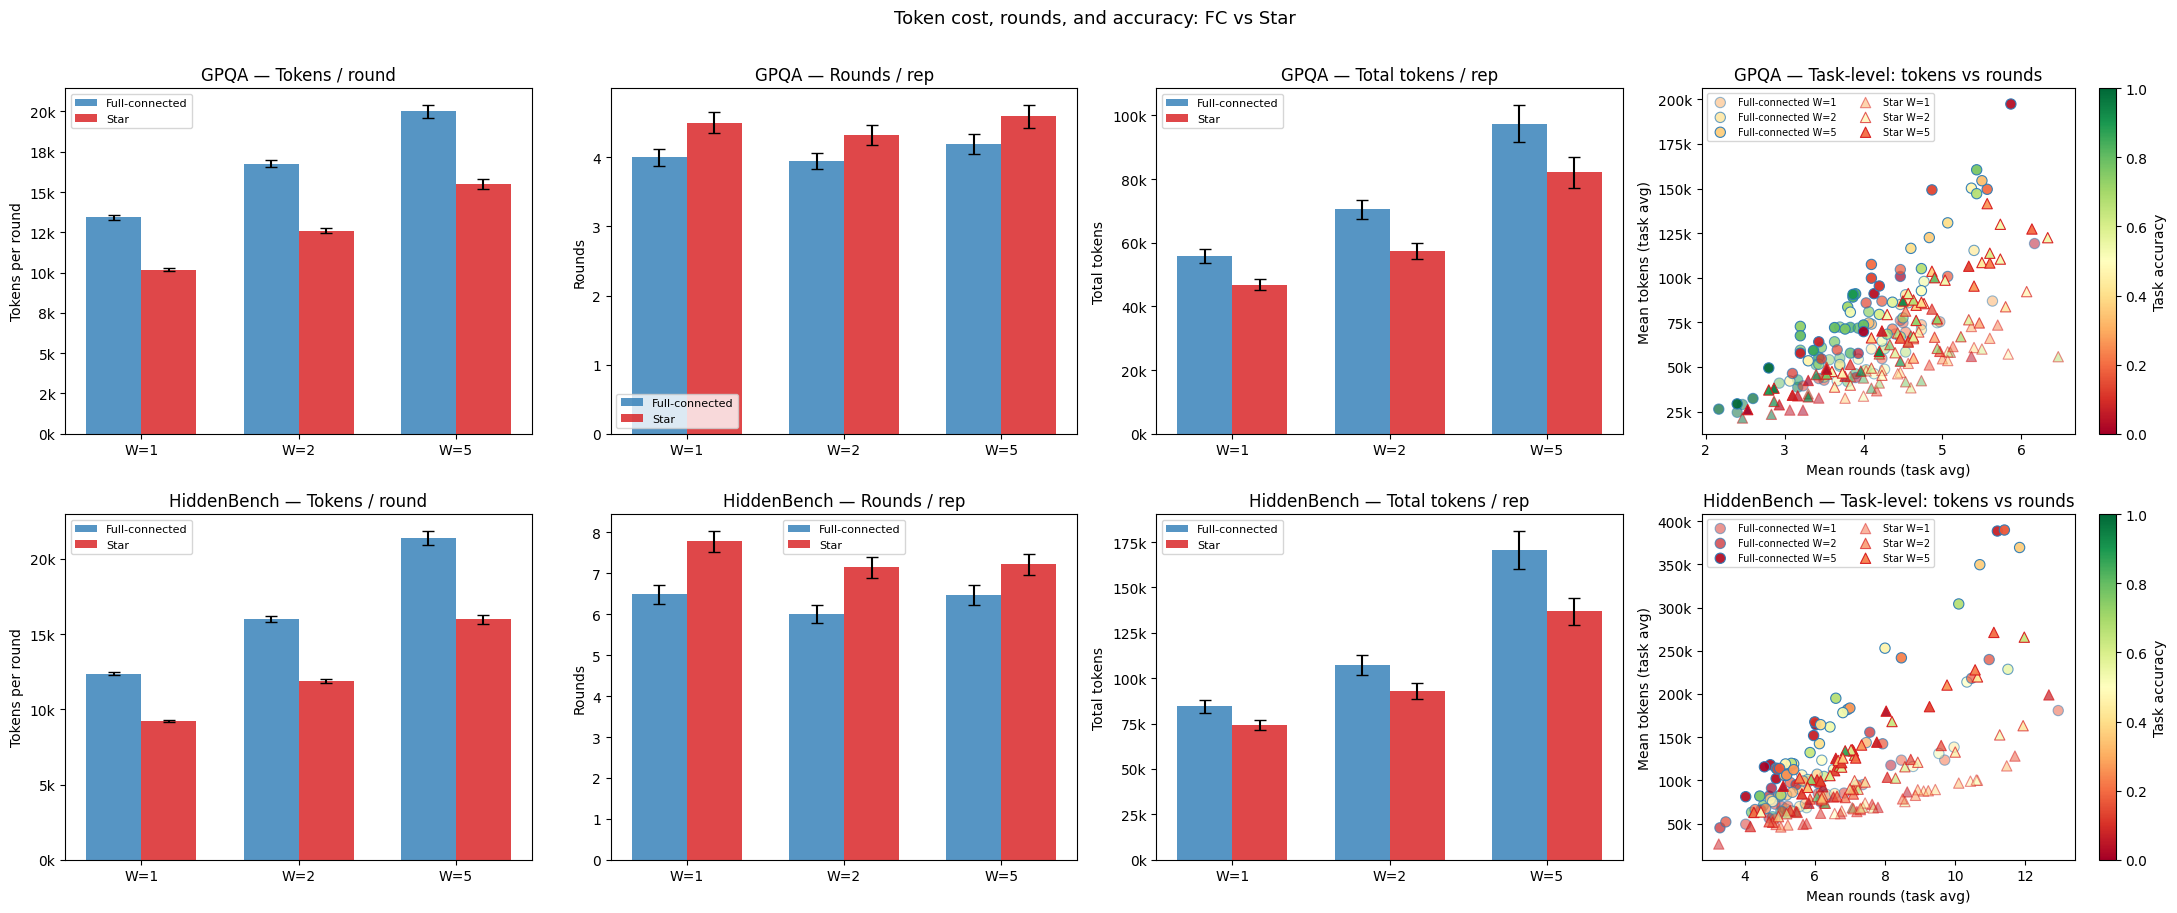

In [108]:
tok_df['tokens_per_round'] = tok_df['total_tokens'] / tok_df['n_rounds']

task_tok_df = (
    tok_df.groupby(['dataset', 'topology', 'W', 'qid'])
    .agg(mean_tokens=('total_tokens', 'mean'),
         mean_rounds=('n_rounds', 'mean'),
         accuracy=('correct', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Token cost, rounds, and accuracy: FC vs Star', fontsize=13, y=1.01)

x     = np.arange(len(W_VALUES))
w_bar = 0.35

for row, ds in enumerate(DATASETS):

    # ── panel 0: tokens per round (structural per-round cost) ─────────────────
    ax = axes[row][0]
    for i, topo in enumerate(TOPOS):
        means = [tok_df[(tok_df['dataset']==ds) & (tok_df['topology']==topo) & (tok_df['W']==w)]['tokens_per_round'].mean()
                 for w in W_VALUES]
        sems  = [tok_df[(tok_df['dataset']==ds) & (tok_df['topology']==topo) & (tok_df['W']==w)]['tokens_per_round'].sem()
                 for w in W_VALUES]
        ax.bar(x + i*w_bar, means, w_bar, yerr=[1.96*s for s in sems],
               color=T_COLORS[topo], alpha=0.8, capsize=4, label=T_LABELS[topo])
    ax.set_xticks(x + w_bar/2)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_title(f'{DS_LABELS[ds]} — Tokens / round')
    ax.set_ylabel('Tokens per round')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))

    # ── panel 1: mean rounds ──────────────────────────────────────────────────
    ax = axes[row][1]
    for i, topo in enumerate(TOPOS):
        means = [tok_df[(tok_df['dataset']==ds) & (tok_df['topology']==topo) & (tok_df['W']==w)]['n_rounds'].mean()
                 for w in W_VALUES]
        sems  = [tok_df[(tok_df['dataset']==ds) & (tok_df['topology']==topo) & (tok_df['W']==w)]['n_rounds'].sem()
                 for w in W_VALUES]
        ax.bar(x + i*w_bar, means, w_bar, yerr=[1.96*s for s in sems],
               color=T_COLORS[topo], alpha=0.8, capsize=4, label=T_LABELS[topo])
    ax.set_xticks(x + w_bar/2)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_title(f'{DS_LABELS[ds]} — Rounds / rep')
    ax.set_ylabel('Rounds')
    ax.legend(fontsize=8)

    # ── panel 2: total tokens per rep (= tokens/round × rounds) ──────────────
    ax = axes[row][2]
    for i, topo in enumerate(TOPOS):
        means = [tok_df[(tok_df['dataset']==ds) & (tok_df['topology']==topo) & (tok_df['W']==w)]['total_tokens'].mean()
                 for w in W_VALUES]
        sems  = [tok_df[(tok_df['dataset']==ds) & (tok_df['topology']==topo) & (tok_df['W']==w)]['total_tokens'].sem()
                 for w in W_VALUES]
        ax.bar(x + i*w_bar, means, w_bar, yerr=[1.96*s for s in sems],
               color=T_COLORS[topo], alpha=0.8, capsize=4, label=T_LABELS[topo])
    ax.set_xticks(x + w_bar/2)
    ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_title(f'{DS_LABELS[ds]} — Total tokens / rep')
    ax.set_ylabel('Total tokens')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))

    # ── panel 3: task-level scatter — mean tokens vs mean rounds ─────────────
    ax = axes[row][3]
    sub_task = task_tok_df[task_tok_df['dataset'] == ds]
    norm = plt.Normalize(vmin=0, vmax=1)
    cmap = plt.cm.RdYlGn
    for topo, marker in zip(TOPOS, ['o', '^']):
        st = sub_task[sub_task['topology'] == topo]
        for w, alpha in zip(W_VALUES, [0.5, 0.7, 0.95]):
            sw = st[st['W'] == w]
            ax.scatter(sw['mean_rounds'], sw['mean_tokens'],
                       c=sw['accuracy'], cmap=cmap, norm=norm,
                       s=55, marker=marker, alpha=alpha,
                       edgecolors=T_COLORS[topo], linewidths=0.8,
                       label=f'{T_LABELS[topo]} W={w}')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax)
    cb.set_label('Task accuracy')
    ax.set_xlabel('Mean rounds (task avg)')
    ax.set_ylabel('Mean tokens (task avg)')
    ax.set_title(f'{DS_LABELS[ds]} — Task-level: tokens vs rounds')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
    ax.legend(fontsize=7, ncol=2, loc='upper left')

plt.tight_layout()
plt.show()